In [1]:
# Import Libraries

import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing import image

In [3]:
# Load Dataset

SRC_TRAIN = r"D:\iit project\dataset10\Training"    # dataset path
SRC_TEST = r"D:\iit project\dataset10\Test"        # dataset path

IMG_SIZE = (128,128)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    DST_TRAIN,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DST_TRAIN,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    DST_TEST,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
print("Train classes:", CLASS_NAMES)

Found 4869 files belonging to 10 classes.
Using 3896 files for training.
Found 4869 files belonging to 10 classes.
Using 973 files for validation.
Found 1633 files belonging to 10 classes.
Train classes: ['Banana 1', 'Cherry 1', 'Cocos 1', 'Kiwi 1', 'Lemon 1', 'Mango 1', 'Peach 1', 'Pineapple 1', 'Strawberry 1', 'Watermelon 1']


In [4]:
# Preprocessing

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
# Build Custom CNN 

from tensorflow.keras import Sequential, layers, Input

cnn_model = Sequential([
    Input(shape=IMG_SIZE + (3,)),       
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(CLASS_NAMES), activation='softmax')  # output = num_classes
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,610 (28.20 MB)

 Trainable params: 7,393,610 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# VGG16 Transfer Learning 

from tensorflow.keras.applications import VGG16

vgg_input = Input(shape=IMG_SIZE + (3,))

# Load base model 
base_vgg = VGG16(weights="imagenet", include_top=False)
base_vgg.trainable = False   # freeze base initially

# Add classification head
x = base_vgg(vgg_input, training=False)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
vgg_output = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

vgg_model = keras.Model(vgg_input, vgg_output)

vgg_model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

vgg_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,682 (60.14 MB)

 Trainable params: 1,049,994 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
# ResNet50 Transfer Learning

from tensorflow.keras.applications import ResNet50

# Define input layer first
resnet_input = Input(shape=IMG_SIZE + (3,))

# Load base model 
base_resnet = ResNet50(weights="imagenet", include_top=False)
base_resnet.trainable = False

# Add classification head

y = base_resnet(resnet_input, training=False)
y = layers.GlobalAveragePooling2D()(y)
y = layers.Dense(128, activation="relu")(y)
resnet_output = layers.Dense(len(CLASS_NAMES), activation="softmax")(y)

resnet_model = keras.Model(resnet_input, resnet_output)

resnet_model.compile(optimizer="adam",
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])

resnet_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
# Train All Models

EPOCHS = 5   # increase later if needed

# Train Custom CNN
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Train VGG16
vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Train ResNet50
resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.8465 - loss: 44.9409 - val_accuracy: 0.9661 - val_loss: 0.1006
Epoch 2/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 3/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - accuracy: 1.0000 - loss: 2.0968e-04 - val_accuracy: 1.0000 - val_loss: 7.6739e-05
Epoch 4/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step - accuracy: 1.0000 - loss: 1.2412e-05 - val_accuracy: 1.0000 - val_loss: 5.7786e-05
Epoch 5/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 1.0000 - loss: 7.5297e-06 - val_accuracy: 1.0000 - val_loss: 4.7773e-05
Epoch 1/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 95s 768ms/step - accuracy: 0.9571 - loss: 2.1566 - val_accuracy: 1.0000 - val_loss: 7.0006e-05
Epoch 2/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 91s 751ms/step - accuracy: 1.0000 - loss: 5.1147e-06 - val_accuracy: 1.0000 - val_loss: 5.2288e-05
Epoch 3/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 90s 741ms/step

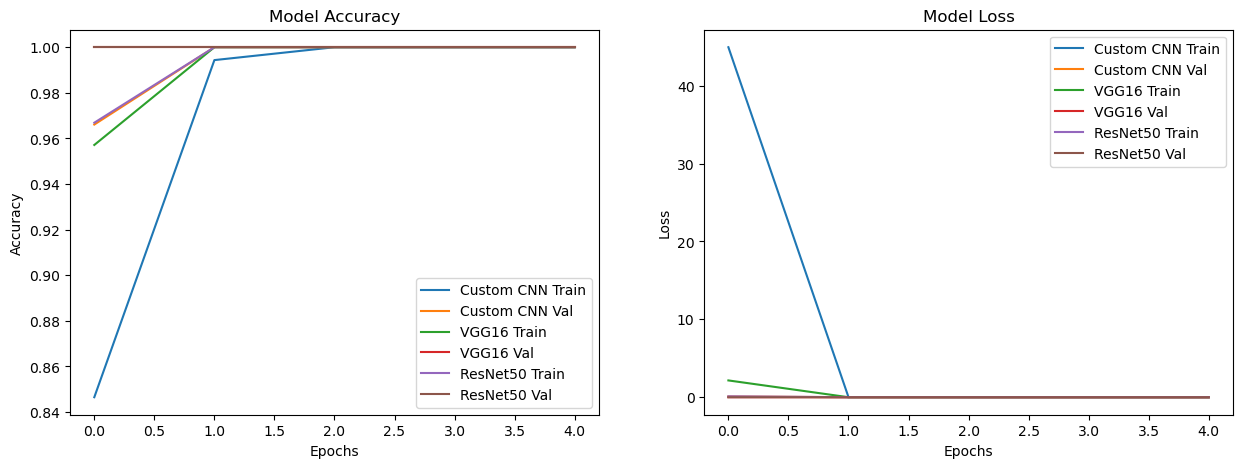


 Final Model Comparison:
        Model  Test Accuracy
0  Custom CNN       0.963870
1       VGG16       0.990814
2    ResNet50       1.000000


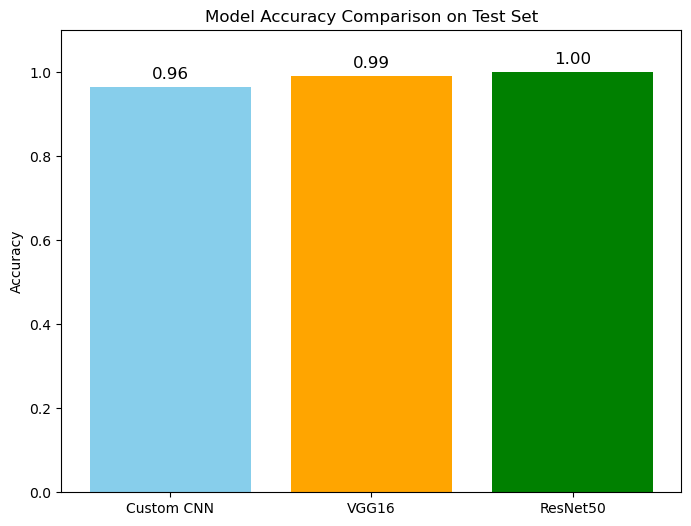

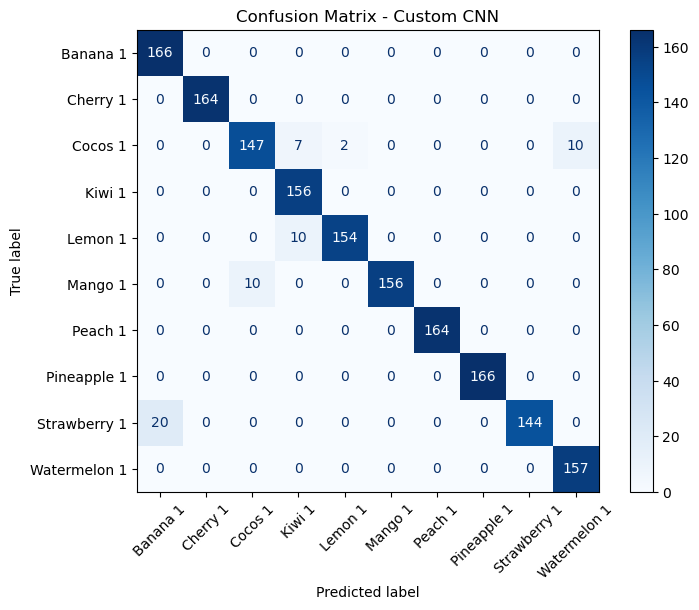

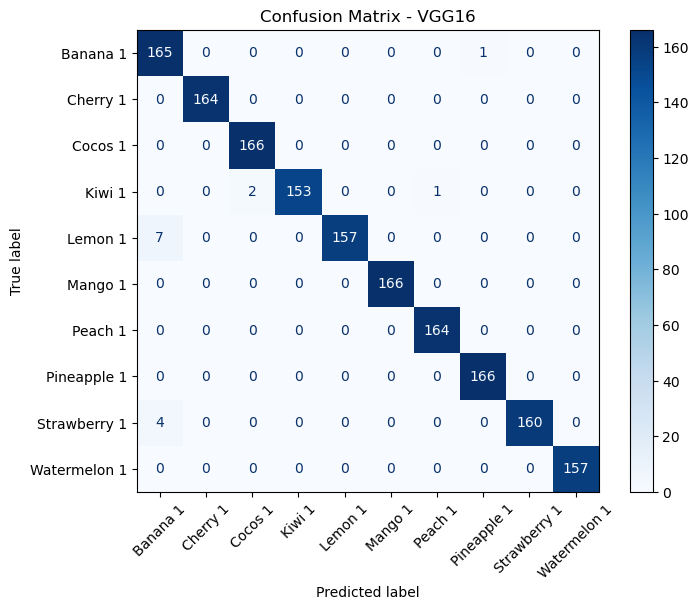

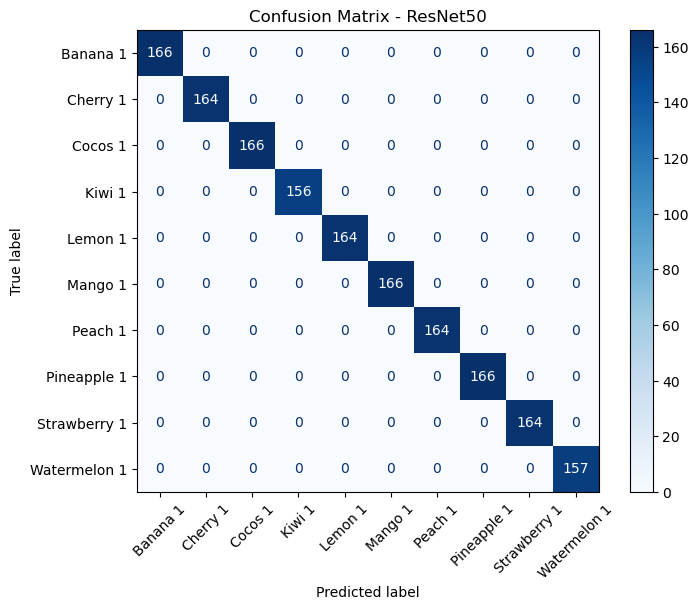

In [10]:
# Model Evaluation & Visualization

import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_history(histories, titles):
    plt.figure(figsize=(15,5))

    # Accuracy subplot
    plt.subplot(1,2,1)
    for hist, label in zip(histories, titles):
        plt.plot(hist.history['accuracy'], label=f'{label} Train')
        plt.plot(hist.history['val_accuracy'], label=f'{label} Val')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss subplot
    plt.subplot(1,2,2)
    for hist, label in zip(histories, titles):
        plt.plot(hist.history['loss'], label=f'{label} Train')
        plt.plot(hist.history['val_loss'], label=f'{label} Val')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(
    [cnn_history, vgg_history, resnet_history],
    ["Custom CNN", "VGG16", "ResNet50"]
)


# Comparison Table + CSV + Bar Plot
cnn_acc = cnn_model.evaluate(test_ds, verbose=0)[1]
vgg_acc = vgg_model.evaluate(test_ds, verbose=0)[1]
resnet_acc = resnet_model.evaluate(test_ds, verbose=0)[1]

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "VGG16", "ResNet50"],
    "Test Accuracy": [cnn_acc, vgg_acc, resnet_acc]
})

print("\n Final Model Comparison:")
print(comparison_df)
comparison_df.to_csv("model_comparison.csv", index=False)

# Bar chart
plt.figure(figsize=(8,6))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"], color=['skyblue','orange','green'])
plt.title("Model Accuracy Comparison on Test Set")
plt.ylabel("Accuracy")
plt.ylim(0,1.1)
for i, acc in enumerate(comparison_df["Test Accuracy"]):
    plt.text(i, acc+0.02, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()


# Confusion Matrices for All Models
def plot_conf_matrix(model, model_name, test_ds, class_names):
    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45, values_format="d", ax=plt.gca())
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

plot_conf_matrix(cnn_model, "Custom CNN", test_ds, CLASS_NAMES)
plot_conf_matrix(vgg_model, "VGG16", test_ds, CLASS_NAMES)
plot_conf_matrix(resnet_model, "ResNet50", test_ds, CLASS_NAMES)


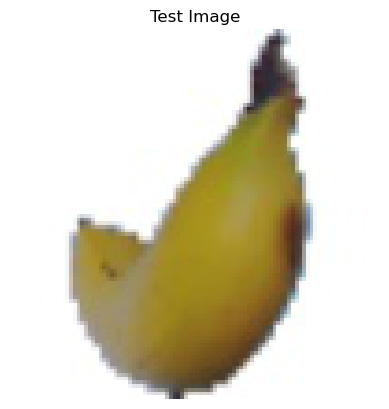

Custom CNN → Predicted: Banana 1 (confidence: 0.12)
VGG16 → Predicted: Banana 1 (confidence: 0.53)
ResNet50 → Predicted: Banana 1 (confidence: 0.23)


In [11]:
# Prediction & Demo

# Keep all models in a dictionary
models_dict = {
    "Custom CNN": cnn_model,
    "VGG16": vgg_model,
    "ResNet50": resnet_model
}

# Function to predict a single image

from tensorflow.keras.preprocessing import image

def predict_image(model, img_path):
    try:
        img = image.load_img(img_path, target_size=IMG_SIZE)
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0) / 255.0   # normalize
        preds = model.predict(x, verbose=0)
        label = CLASS_NAMES[np.argmax(preds)]
        conf = np.max(preds)
        return label, conf
    except Exception as e:
        print(f"Error loading image: {e}")
        return None, None

# Test on one image
sample_path = r"D:\iit project\dataset10\test\Banana 1\12_100.jpg"  # <-- change path
plt.imshow(image.load_img(sample_path))
plt.axis("off")
plt.title("Test Image")
plt.show()

# Run predictions for all models
for name, model in models_dict.items():
    label, conf = predict_image(model, sample_path)
    if label is not None:
        print(f"{name} → Predicted: {label} (confidence: {conf:.2f})")
